# Exploratory Data Analysis -- Demographic Data

Dataset covers **195 countries** with three core metrics: birth rate, internet users (% of population), and income group classification.

## 1. Setup

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme()
plt.rcParams["figure.figsize"] = (12, 5)

## 2. Load Data

In [2]:
df = pd.read_csv("data/demographic_data.csv")
df.head()

,Country Name,Country Code,Birth Rate,Internet Users,Income Group
0,Aruba,ABW,10.244,78.9,High income
1,Afghanistan,AFG,35.253,5.9,Low income
2,Angola,AGO,45.985,19.1,Upper middle income
3,Albania,ALB,12.877,57.2,Upper middle income
4,United Arab Emirates,ARE,11.044,88.0,High income


## 3. Dataset Overview

In [3]:
print("Shape:", df.shape)

Shape: (195, 5)


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 195 entries, 0 to 194
Data columns (total 5 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Country Name    195 non-null    str    
 1   Country Code    195 non-null    str    
 2   Birth Rate      195 non-null    float64
 3   Internet Users  195 non-null    float64
 4   Income Group    195 non-null    str    
dtypes: float64(2), str(3)
memory usage: 12.9 KB


In [7]:
df.describe().round(2)

,Birth Rate,Internet Users
count,195.00,195.00
mean,21.47,42.08
std,10.61,29.03
min,7.90,0.90
25%,12.12,14.52
50%,19.68,41.00
75%,29.76,66.22
max,49.66,96.55


## 4. Missing Values

In [8]:
df.isnull().sum()

Country Name      0
Country Code      0
Birth Rate        0
Internet Users    0
Income Group      0
dtype: int64

## 5. Categorical Analysis

In [9]:
df["Income Group"].value_counts()

Income Group
High income            67
Lower middle income    50
Upper middle income    48
Low income             30
Name: count, dtype: int64

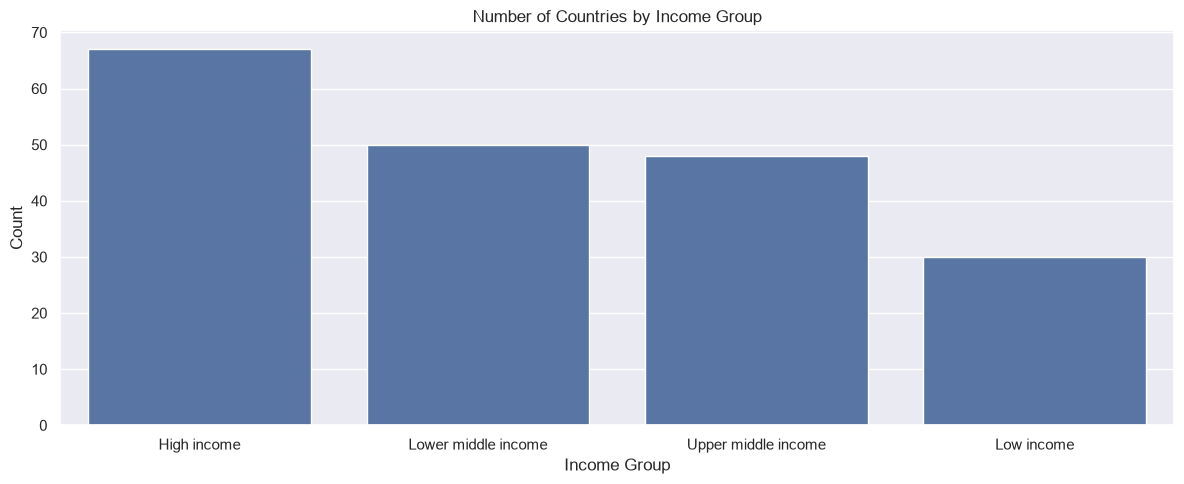

In [10]:
income_counts = df["Income Group"].value_counts().reset_index()
income_counts.columns = ["Income Group", "Count"]

sns.barplot(data=income_counts, x="Income Group", y="Count")
plt.title("Number of Countries by Income Group")
plt.tight_layout()
plt.show()

## 6. Distributions

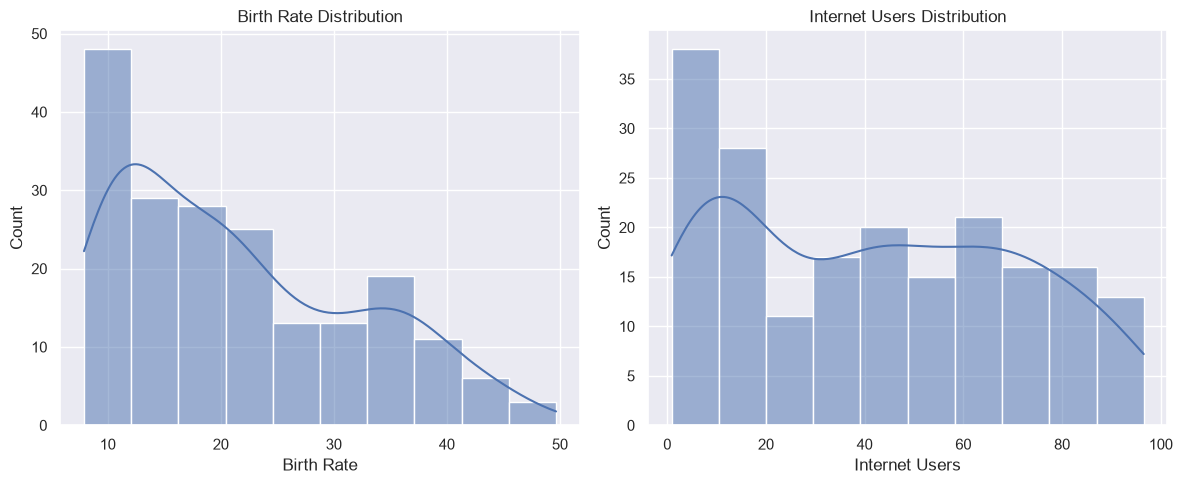

In [11]:
fig, axes = plt.subplots(1, 2)

sns.histplot(df["Birth Rate"], bins=10, kde=True, ax=axes[0])
axes[0].set_title("Birth Rate Distribution")

sns.histplot(df["Internet Users"], bins=10, kde=True, ax=axes[1])
axes[1].set_title("Internet Users Distribution")

plt.tight_layout()
plt.show()

## 7. Box Plots by Income Group

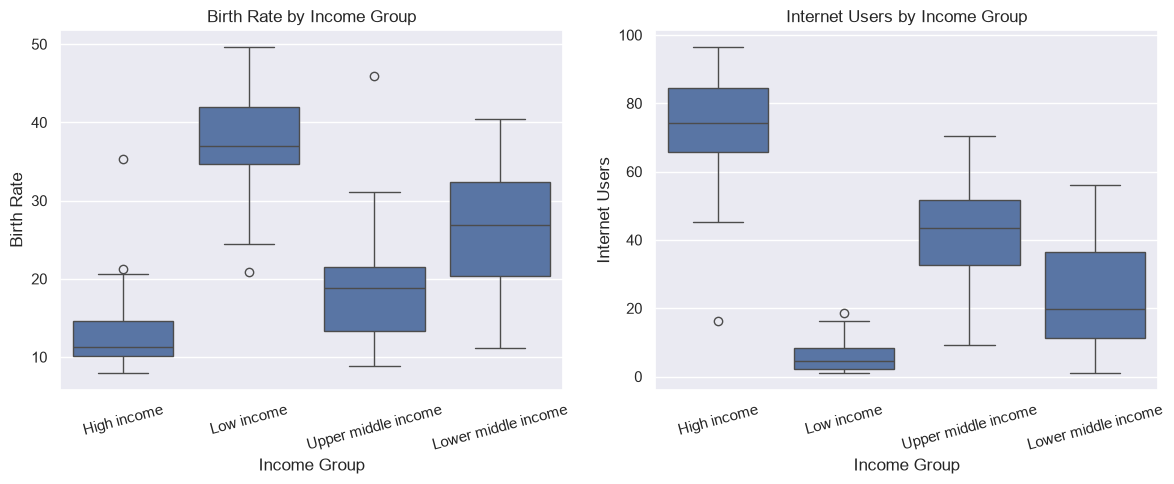

In [12]:
fig, axes = plt.subplots(1, 2)

sns.boxplot(data=df, x="Income Group", y="Birth Rate", ax=axes[0])
axes[0].set_title("Birth Rate by Income Group")
axes[0].tick_params(axis="x", rotation=15)

sns.boxplot(data=df, x="Income Group", y="Internet Users", ax=axes[1])
axes[1].set_title("Internet Users by Income Group")
axes[1].tick_params(axis="x", rotation=15)

plt.tight_layout()
plt.show()

## 8. Correlation

In [14]:
df[["Birth Rate", "Internet Users"]].corr().round(2)

,Birth Rate,Internet Users
Birth Rate,1.00,-0.82
Internet Users,-0.82,1.00


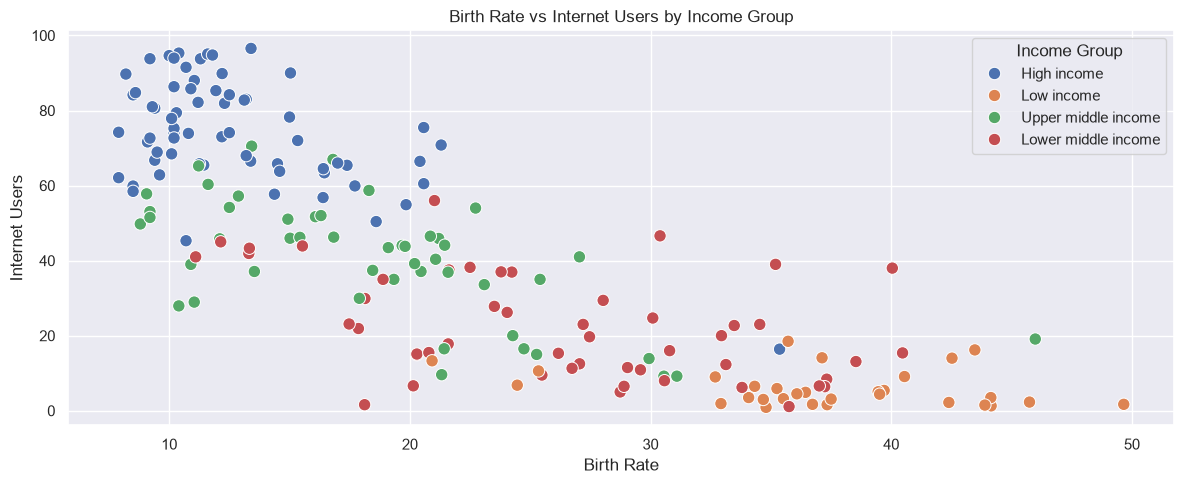

In [15]:
sns.scatterplot(
    data=df,
    x="Birth Rate",
    y="Internet Users",
    hue="Income Group",
    s=80,
)
plt.title("Birth Rate vs Internet Users by Income Group")
plt.tight_layout()
plt.show()